# Dispersion-Assisted Gerchberg-Saxton — a NumPy Prototype

**Civilian optical measurement.** Recover the phase $\phi(t)$ of an optical field from two
intensity-only ("square-law detector") measurements — one before and one after a known fibre
dispersion. This is the carrier-less coherent receiver idea: no local oscillator, just two power
detectors and a spool of fibre. For fibre metrology, silicon photonics, detector modeling, and
teaching — not a weapon or directed-energy system.

$$x(t)=A(t)e^{i\phi(t)},\qquad H(f)=e^{i\pi D f^2},\qquad
I_1=|x|^2,\quad I_2=|\mathcal F^{-1}\{H\,\mathcal F x\}|^2.$$

We generate synthetic data, export it (CSV + NPZ), run the Gerchberg-Saxton loop, and — honestly —
diagnose *when it recovers and when it cannot*. Driven by the reusable script
`dispersion_gs_prototype.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from dgs import dispersion_gs_prototype as dg

print("dispersion_gs_prototype loaded")

dispersion_gs_prototype loaded


## §1 The hidden field and the two intensity planes

$A(t)$ is a Gaussian main pulse plus a weak satellite; $\phi(t)$ has a quadratic chirp, a sinusoidal
ripple, and a little band-limited random texture. We never get to see $\phi$ — only the two
intensities $I_1$ (before) and $I_2$ (after dispersion $D$), each in a clean and a detector-noisy
version.

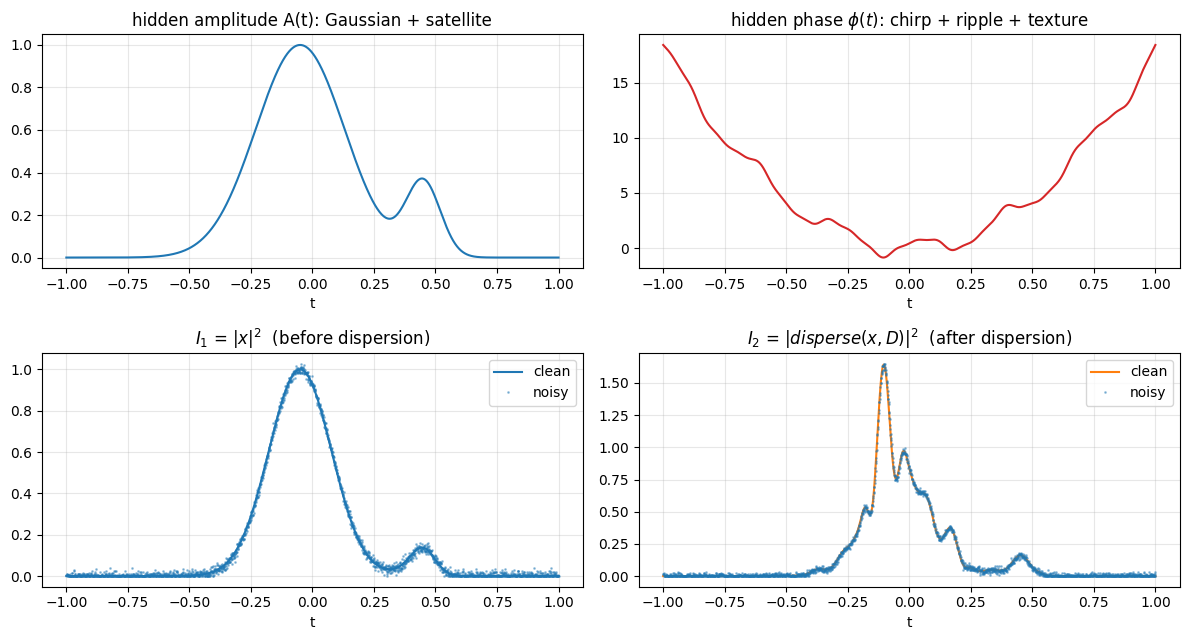

In [2]:
data = dg.make_measurements(N=2048, D=6000.0, snr_db=30.0, seed=0)
t = data["t"]

fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))
ax[0, 0].plot(t, data["A"], "C0"); ax[0, 0].set_title("hidden amplitude A(t): Gaussian + satellite")
ax[0, 1].plot(t, data["phi"], "C3"); ax[0, 1].set_title("hidden phase $\\phi(t)$: chirp + ripple + texture")
ax[1, 0].plot(t, data["I1_clean"], "C0", label="clean")
ax[1, 0].plot(t, data["I1_noisy"], ".", ms=2, alpha=0.4, label="noisy")
ax[1, 0].set_title("$I_1$ = $|x|^2$  (before dispersion)"); ax[1, 0].legend()
ax[1, 1].plot(t, data["I2_clean"], "C1", label="clean")
ax[1, 1].plot(t, data["I2_noisy"], ".", ms=2, alpha=0.4, label="noisy")
ax[1, 1].set_title("$I_2$ = $|disperse(x,D)|^2$  (after dispersion)"); ax[1, 1].legend()
for a in ax.flat:
    a.grid(alpha=0.3); a.set_xlabel("t")
plt.tight_layout(); plt.show()

## §2 Export the data — CSV and NPZ

CSV for spreadsheets / quick inspection; NPZ for fast NumPy reload. Both carry the hidden truth
($A$, $\phi$) alongside the measurements so a downstream script can score any recovery.

In [3]:
root = pathlib.Path.cwd().parent
(root / "data").mkdir(exist_ok=True)
csv_path = dg.export_csv(root / "data" / "dispersion_gs_prototype.csv", data)
npz_path = dg.export_npz(root / "data" / "dispersion_gs_prototype.npz", data)
print("wrote", csv_path.name, "and", npz_path.name)

reload = np.load(npz_path)
print("NPZ keys:", list(reload.keys()), "| D =", float(reload["D"]))

wrote dispersion_gs_prototype.csv and dispersion_gs_prototype.npz
NPZ keys: ['t', 'D', 'A_true', 'phi_true', 'I1_clean', 'I2_clean', 'I1_noisy', 'I2_noisy'] | D = 6000.0


## §3 Gerchberg-Saxton recovery

The exact loop requested: initialise from $\sqrt{I_1}$ with random phase; propagate to plane 2,
replace the amplitude with $\sqrt{I_2}$; back-propagate, replace with $\sqrt{I_1}$; iterate; compare
the recovered phase to the truth (up to the unavoidable global-offset and conjugate ambiguities).

recovered phase RMS error = 1.681 rad
GS amplitude mismatch: 0.345 -> 0.089


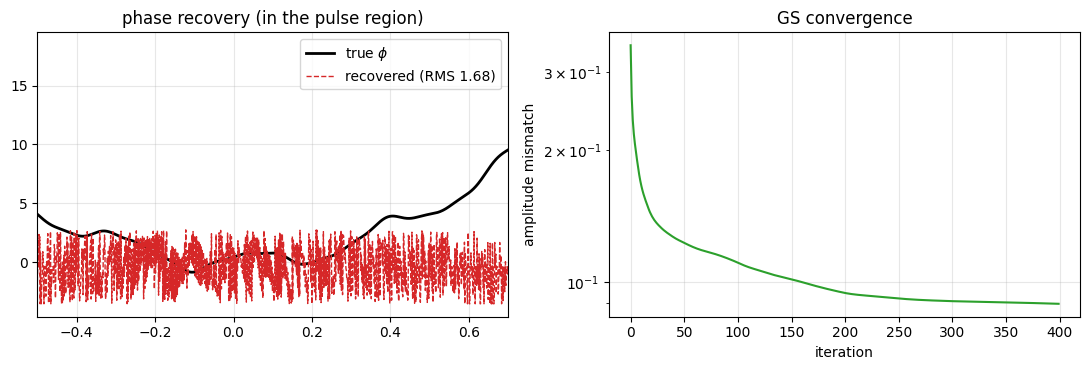

In [4]:
x_rec, errors = dg.gerchberg_saxton(data["I1_noisy"], data["I2_noisy"], data["D"],
                                    n_iter=400, seed=0)
rms, phi_aligned = dg.compare_phase(np.angle(x_rec), data["phi"], data["A"]**2)
print(f"recovered phase RMS error = {rms:.3f} rad")
print(f"GS amplitude mismatch: {errors[0]:.3f} -> {errors[-1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(t, data["phi"], "k", lw=2, label="true $\\phi$")
ax[0].plot(t, phi_aligned, "C3--", lw=1, label=f"recovered (RMS {rms:.2f})")
ax[0].set_xlim(-0.5, 0.7); ax[0].set_title("phase recovery (in the pulse region)"); ax[0].legend()
ax[1].semilogy(errors, "C2"); ax[1].set_title("GS convergence")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("amplitude mismatch")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §4 Honest diagnosis — why this is the *hard* case

The recovery above is poor, and that is a real result worth understanding, not a bug:

1. **Diversity.** GS needs $I_1$ and $I_2$ to genuinely *differ*. With one plane undispersed and a
   Gaussian-dominated pulse, $I_2$ stays highly correlated with $I_1$ — a chirped Gaussian disperses
   into another Gaussian. Measure it:

In [5]:
for D in (1500, 6000, 12000, 20000):
    I2 = np.abs(dg.disperse(data["x"], D))**2
    print(f"  D={D:>5}: corr(I1, I2) = {np.corrcoef(data['I1_clean'], I2)[0,1]:.3f}")
print("  -> high correlation = low diversity = little phase information in I2.")

  D= 1500: corr(I1, I2) = 0.993
  D= 6000: corr(I1, I2) = 0.945
  D=12000: corr(I1, I2) = 0.883
  D=20000: corr(I1, I2) = 0.831
  -> high correlation = low diversity = little phase information in I2.


2. **GS stagnation for varying-envelope signals.** The amplitude mismatch above plateaus instead
   of going to zero — the alternating projections get trapped. This is the classic failure mode that
   motivated Fienup's HIO and two-dispersion schemes; constant-envelope signals (QPSK-like) avoid it.

The repo's own rule of thumb (`|D| >= 5000`, well-separated dispersions) exists for exactly this
reason. So let's show the **well-posed regime** where the *same* algorithm succeeds.

## §5 The well-posed regime — two dispersions + constant envelope

Use **two nonzero dispersions** (a tap before and after a fibre segment) and a constant-envelope,
spectrally-rich phase signal — the carrier-less-receiver sweet spot. The repo's tested
`gs_core.retrieve_phase` recovers it to a few hundredths of a radian.

well-posed (two dispersions, constant envelope): RMS = 0.061 rad
  corr(I1,I2) = 0.370 (well decorrelated)


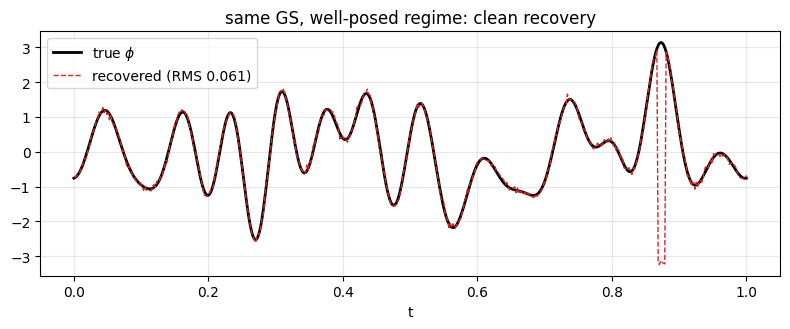

In [6]:
from dgs import gs_core as gs
wp = gs.make_qpsk_measurements(n_symbols=64, sps=8, D1=-5000.0, D2=-5750.0, snr_db=25.0)
phi_wp, err_wp = gs.retrieve_phase(wp["I1"], wp["I2"], wp["D1"], wp["D2"],
                                   n_iter=60, unit_amplitude=True)

def align(pr, pt):
    best = None
    for s in (1, -1):
        d = pt - s*pr; off = np.angle(np.sum(np.exp(1j*d)))
        e = np.sqrt(np.mean(np.angle(np.exp(1j*(d-off)))**2))
        best = e if best is None else min(best, e)
    return best
rms_wp = align(phi_wp, wp["phi_true"])
print(f"well-posed (two dispersions, constant envelope): RMS = {rms_wp:.3f} rad")
print(f"  corr(I1,I2) = {np.corrcoef(wp['I1'], wp['I2'])[0,1]:.3f} (well decorrelated)")

tw = wp["t"]
plt.figure(figsize=(8, 3.4))
plt.plot(tw, wp["phi_true"], "k", lw=2, label="true $\\phi$")
off = np.angle(np.sum(np.exp(1j*(wp["phi_true"] - phi_wp))))
plt.plot(tw, phi_wp + off, "C3--", lw=1, label=f"recovered (RMS {rms_wp:.3f})")
plt.title("same GS, well-posed regime: clean recovery"); plt.legend(); plt.xlabel("t")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §6 What the prototype shows

- **The pipeline is real and reusable.** `dispersion_gs_prototype.py` generates the field, applies the
  dispersion $H(f)=e^{i\pi Df^2}$, models detector noise, exports CSV/NPZ, runs GS, and scores the
  recovery — a clean base to swap in *measured* $I_1, I_2$ from a real fibre setup.
- **Phase retrieval is governed by diversity.** §4 makes concrete why the carrier-less receiver needs
  strong, well-separated dispersion: without it $I_1\approx I_2$ and the phase is simply not in the
  data. §5 shows the same algorithm succeeding once that condition is met.
- **Honesty as a feature.** The hard case here (single dispersion, varying-envelope, Gaussian-dominated)
  is exactly where naive GS stagnates — knowing that tells you to reach for two dispersions, a
  constant-envelope drive, or Fienup HIO with a support/oversampling constraint.

Civilian scope throughout: optical-fibre measurement, silicon photonics, phase retrieval, detector
modeling, education. Files: `dispersion_gs_prototype.py` (reusable script),
`data/dispersion_gs_prototype.{csv,npz}` (exports), this notebook (plots + diagnosis).